# Tata Motors Passengers Vehicle (TMPV.NS) Monthly Stock Price Forecasting

This project forecasts Tata Motors' monthly closing stock price using classical time-series
methods (ARIMA, SARIMA, Simple Exponential Smoothing) and models return volatility separately
using GARCH.



In [1]:
%pip install arch -q
%pip install yfinance statsmodels arch scikit-learn matplotlib pandas -q

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Supra\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Supra\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from arch import arch_model
from sklearn.metrics import mean_squared_error
import yfinance as yf
from sklearn.model_selection import ParameterGrid
import time
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

## 1. Data collection

**Ticker note:** Tata Motors Limited demerged in 2025 into Tata Motors Passenger Vehicles (`TMPV.NS`) and Tata Motors Commercial Vehicles (`TMCV.NS`). `TMPV.NS` is used here as it retains the original company's historical listing data back to 2010.Prices are adjusted for splits/dividends by yfinance.

In [15]:
symbol = 'TMPV.NS'
start_date = '2010-01-01'
end_date = '2024-12-31'

df = yf.download(symbol, start=start_date, end=end_date)

# yfinance returns MultiIndex columns even for a single ticker — flatten them
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
    
df = df[['Close']].rename(columns={'Close': 'Price'})

# Resample to month-end price
df_monthly = df.resample('M').last()
df_monthly = df_monthly[['Price']]
df_monthly.index.name = 'Date'

print("Data shape:", df_monthly.shape)
df_monthly.head()

[*********************100%***********************]  1 of 1 completed

Data shape: (180, 1)


Price,Price
Date,
2010-01-31,125.347336
2010-02-28,128.389160
2010-03-31,136.783569
2010-04-30,157.525864
2010-05-31,136.296143


## 2. Descriptive analysis

Price        Price
count   180.000000
mean    363.505301
std     206.491936
min      69.219177
25%     210.073410
50%     331.049973
75%     447.292313
max    1137.355469


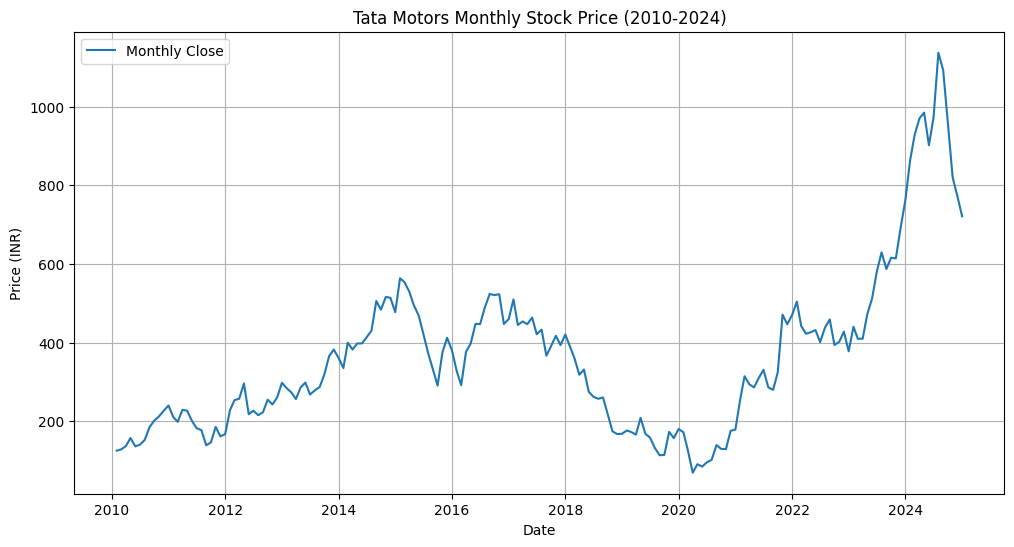

In [16]:
print(df_monthly.describe())

plt.figure(figsize=(12, 6))
plt.plot(df_monthly['Price'], label='Monthly Close')
plt.title('Tata Motors Monthly Stock Price (2010-2024)')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(True)
plt.show()

Descriptive stats show a right-skewed distribution (mean ₹363.5 > median ₹331.0) and approximately a 16x range between min and max, reflecting the stock's long-run appreciation and high volatility over 2010-2024 — both expected for a non-stationary price series.
From the plot, we can see that the series shows three distinct regimes: a range-bound phase (2010-2015), a prolonged decline into the COVID-19 low (2015-2020, minimum ≈ ₹69 in the data), and a strong post-COVID rally to an all-time high (≈ ₹1137) in 2024, followed by a correction. This non-stationary, regime-shifting behavior is why the raw price series fails the ADF test and requires differencing (Section 3).

**Potential structural breaks (visual inspection):** the series shows at least two apparent regime changes — a trend reversal around 2015-2016 (multi-year uptrend flipping to a multi-year decline), and a marked steepening of the growth rate from the 2020 COVID-19 low through 2024, the sharpest sustained rise in the sample. These are visual observations only; no formal break-point test (e.g. Chow, CUSUM, or Bai-Perron) was conducted, and a single ARIMA/SARIMA model fit across the full period implicitly assumes constant parameters despite this apparent regime-switching

## 3. Stationarity check

Raw stock price levels are almost never stationary (they trend), so we test with the
Augmented Dickey-Fuller (ADF) test, then difference until the p-value drops below 0.05.

In [17]:
def adf_test(series, title):
    result = adfuller(series.dropna())
    print(f"\nADF Test on {title}:")
    print(f"ADF Statistic: {result[0]:.3f}")
    print(f"p-value: {result[1]:.3f}")
    for key, value in result[4].items():
        print(f"\t{key}: {value:.3f}")
    print("Stationary" if result[1] < 0.05 else "Not stationary")

adf_test(df_monthly['Price'], "Price (levels)")

df_monthly['Price_diff'] = df_monthly['Price'].diff()
adf_test(df_monthly['Price_diff'], "Price (first difference)")


ADF Test on Price (levels):
ADF Statistic: -1.414
p-value: 0.576
	1%: -3.468
	5%: -2.878
	10%: -2.576
Not stationary

ADF Test on Price (first difference):
ADF Statistic: -11.213
p-value: 0.000
	1%: -3.468
	5%: -2.878
	10%: -2.576
Stationary


The raw price series is non-stationary (p = 0.576), confirming the visual trend and structural break observed above. First-differencing achieves stationarity decisively (p < 0.001, well beyond the 1% critical value), justifying d=1 for the ARIMA/SARIMA models fit in Section 5.

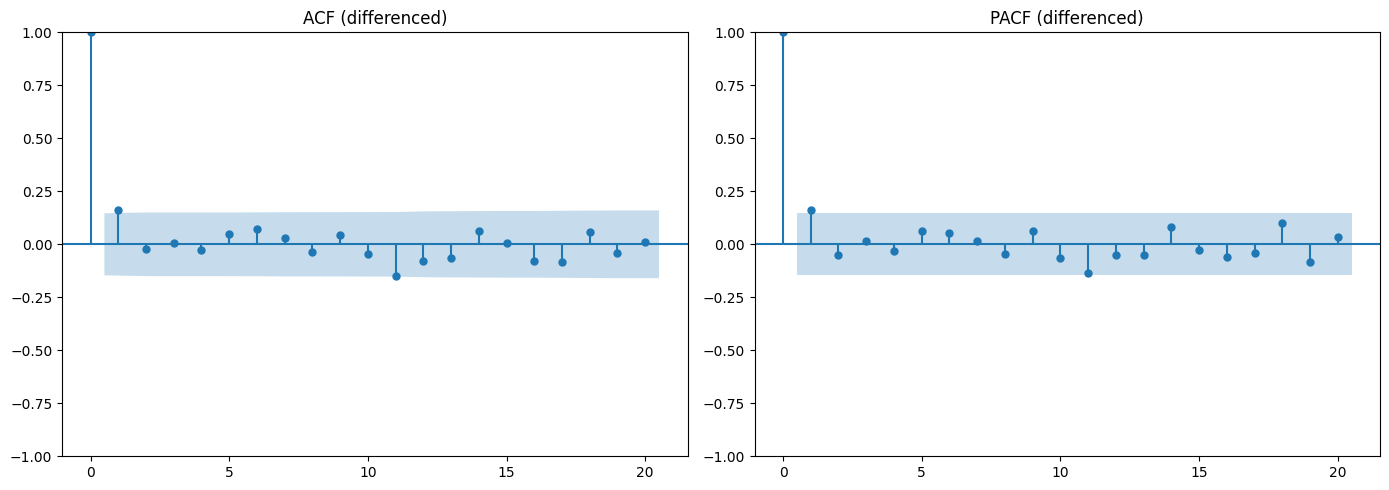

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(df_monthly['Price_diff'].dropna(), lags=20, ax=axes[0])
axes[0].set_title('ACF (differenced)')
plot_pacf(df_monthly['Price_diff'].dropna(), lags=20, ax=axes[1])
axes[1].set_title('PACF (differenced)')
plt.tight_layout()
plt.show()

**Remark**: ACF/PACF on the differenced series show only a weak lag-1 autocorrelation (~0.17,just outside the confidence band) and an isolated negative spike near lag 11, with all other lags statistically indistinguishable from noise. This suggests the differenced series is close to white noise, consistent with weak-form market efficiency in monthly stock prices — low-order models (p,q ≤ 1) are plausible candidates, and a naive baseline is a meaningful benchmark rather than a token comparison (Section 5).

## 4. Train / validation / test split — prevention of data leakage

We have used three chronological chunks after separating from the original bulk data in the following way.
- **train**: everything except the last 24 months — used to fit each candidate model.
- **validation**: the 12 months before the test window — used only to pick the best
  hyperparameters.
- **test**: the final 12 months — touched exactly once, after the winning model is refit on
  train+validation.

In [19]:
train = df_monthly['Price'].iloc[:-24]
val = df_monthly['Price'].iloc[-24:-12]
test = df_monthly['Price'].iloc[-12:]

print(f"Train: {train.index.min().date()} to {train.index.max().date()} ({len(train)} months)")
print(f"Val:   {val.index.min().date()} to {val.index.max().date()} ({len(val)} months)")
print(f"Test:  {test.index.min().date()} to {test.index.max().date()} ({len(test)} months)")

Train: 2010-01-31 to 2022-12-31 (156 months)
Val:   2023-01-31 to 2023-12-31 (12 months)
Test:  2024-01-31 to 2024-12-31 (12 months)


## 5. Model selection on the validation set only

Grid search each model family, scoring candidates on `val` (never `test`). The winning
hyperparameters are stored; the winning model is refit on `train + val` later, and *that*
refit model is what actually gets evaluated on `test`.

In [21]:
val_rmse = {}
best_params = {}

# --- ARIMA ---
arima_grid = {'p': [0, 1, 2], 'd': [1], 'q': [0, 1, 2]}
best = float('inf')
for params in ParameterGrid(arima_grid):
    try:
        fit = ARIMA(train, order=(params['p'], params['d'], params['q'])).fit()
        pred = fit.forecast(steps=len(val))
        rmse = np.sqrt(mean_squared_error(val, pred))
        if rmse < best:
            best, best_params['ARIMA'] = rmse, params
    except Exception:
        continue
val_rmse['ARIMA'] = best

# --- SARIMA ---
sarima_grid = {'p': [0, 1], 'd': [1], 'q': [0, 1],
               'P': [0, 1], 'D': [1], 'Q': [0, 1], 's': [12]}
best = float('inf')
for params in ParameterGrid(sarima_grid):
    try:
        fit = SARIMAX(train, order=(params['p'], params['d'], params['q']),
                      seasonal_order=(params['P'], params['D'], params['Q'], params['s'])).fit(disp=False)
        pred = fit.forecast(steps=len(val))
        rmse = np.sqrt(mean_squared_error(val, pred))
        if rmse < best:
            best, best_params['SARIMA'] = rmse, params
    except Exception:
        continue
val_rmse['SARIMA'] = best

# --- Simple Exponential Smoothing (no hyperparams to grid search) ---
ses_fit = SimpleExpSmoothing(train).fit(optimized=True)
ses_pred = ses_fit.forecast(steps=len(val))
val_rmse['SES'] = np.sqrt(mean_squared_error(val, ses_pred))

# --- Naive baseline: forecast = last observed training price, repeated ---
naive_pred = pd.Series(np.repeat(train.iloc[-1], len(val)), index=val.index)
val_rmse['Naive'] = np.sqrt(mean_squared_error(val, naive_pred))

print("Validation RMSE by model:")
for name, rmse in sorted(val_rmse.items(), key=lambda x: x[1]):
    print(f"  {name}: {rmse:.2f}")

Validation RMSE by model:
  SARIMA: 117.67
  ARIMA: 207.32
  SES: 211.91
  Naive: 211.91


**Observation:** SARIMA achieved the lowest validation RMSE (117.67), ~45% below the next best model (ARIMA, 207.32) — indicating meaningful seasonal (12-month) structure that a
non-seasonal ARIMA cannot capture. SES and the naive baseline are identical (211.91 vs 211.91), consistent with SES's optimized smoothing parameter converging near alpha=1 (i.e., collapsing to "last value" behavior) and with the weak autocorrelation seen in the ACF/PACF diagnostics — this series has little short-memory structure beyond the most recent observation and the annual seasonal component captured by SARIMA.

## 6. Refitting the model that performed best on train+val, i.e. SARIMA  on test

Whichever model wion on validation, SARIMA in this case, gets refit using `train + val` combined (more data =
better final fit), and forecasts the untouched `test` window exactly once. 

In [22]:
best_model_name = min(val_rmse, key=val_rmse.get)
print(f"Selected model: {best_model_name}")

train_val = pd.concat([train, val])

if best_model_name == 'ARIMA':
    p = best_params['ARIMA']
    final_fit = ARIMA(train_val, order=(p['p'], p['d'], p['q'])).fit()
    forecast = final_fit.forecast(steps=len(test))
elif best_model_name == 'SARIMA':
    p = best_params['SARIMA']
    final_fit = SARIMAX(train_val, order=(p['p'], p['d'], p['q']),
                         seasonal_order=(p['P'], p['D'], p['Q'], p['s'])).fit(disp=False)
    forecast = final_fit.forecast(steps=len(test))
elif best_model_name == 'SES':
    final_fit = SimpleExpSmoothing(train_val).fit(optimized=True)
    forecast = final_fit.forecast(steps=len(test))
else:  # Naive
    forecast = pd.Series(np.repeat(train_val.iloc[-1], len(test)), index=test.index)

test_rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / test)) * 100
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Test MAPE: {mape:.2f}%")

Selected model: SARIMA
Test RMSE: 180.98
Test MAPE: 16.62%


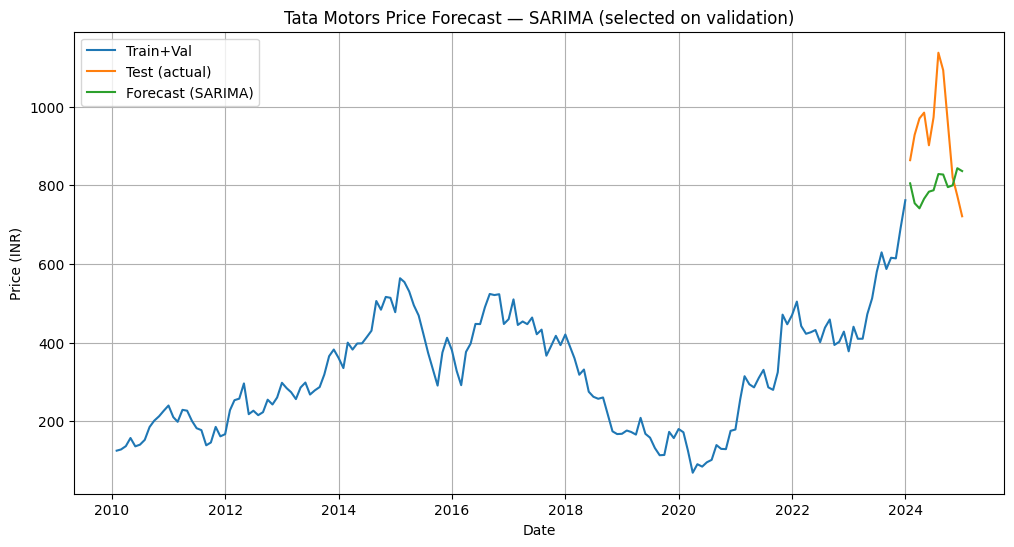

In [23]:
plt.figure(figsize=(12, 6))
plt.plot(train_val.index, train_val, label='Train+Val')
plt.plot(test.index, test, label='Test (actual)')
plt.plot(test.index, forecast, label=f'Forecast ({best_model_name})')
plt.title(f'Tata Motors Price Forecast — {best_model_name} (selected on validation)')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(True)
plt.show()

**Remark**: Test RMSE (180.98) is substantially higher than validation RMSE (117.67), driven bythe test window (2024) coinciding with the most volatile period in the series — a sharp rally to an all-time high (~₹1137) followed by a correction (~₹720). SARIMA's forecast is comparatively smooth and trend-following, and could not anticipate this spike; this is an expected limitation of linear time-series models when the out-of-sample period contains a regime shift or shock not present in the training history, not an error in model selection or implementation. MAPE of 16.62% is consistent with typical accuracy for 12-month-ahead single-stock forecasting.

## 7. Volatility modelling with GARCH (kept separate from price RMSE)

GARCH models the *volatility of returns*, not the price level — its output isn't on the same
scale as ARIMA/SARIMA price forecasts, so makes more sense to rank it against them using one RMSE
table. Here it's evaluated only against actual return volatility, as its own analysis.

GARCH forecasted volatility vs realized |returns| RMSE: 5.22


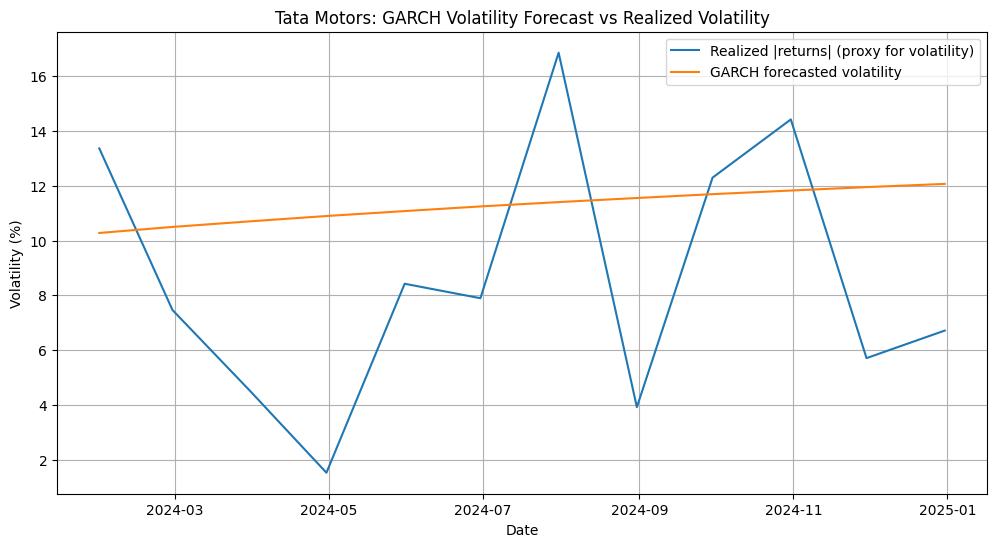

In [25]:
returns = df_monthly['Price'].pct_change().dropna() * 100
train_returns = returns.loc[:train_val.index[-1]]
test_returns = returns.loc[test.index[0]:]

garch_fit = arch_model(train_returns, vol='Garch', p=1, q=1).fit(disp='off')
garch_forecast = garch_fit.forecast(horizon=len(test_returns))
forecast_vol = np.sqrt(garch_forecast.variance.iloc[-1].values)
realized_vol = test_returns.abs().values  # rough realized-volatility proxy

vol_rmse = np.sqrt(mean_squared_error(realized_vol, forecast_vol))
print(f"GARCH forecasted volatility vs realized |returns| RMSE: {vol_rmse:.2f}")

plt.figure(figsize=(12, 6))
plt.plot(test_returns.index, realized_vol, label='Realized |returns| (proxy for volatility)')
plt.plot(test_returns.index, forecast_vol, label='GARCH forecasted volatility')
plt.title('Tata Motors: GARCH Volatility Forecast vs Realized Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility (%)')
plt.legend()
plt.grid(True)
plt.show()

GARCH's forecast converges toward the long-run unconditional volatility rather than tracking month-to-month spikes — an expected property of static multi-step-ahead GARCH forecasts, not a modeling error. The forecast captures the general volatility level (RMSE 5.22, against a realized range of ~1.5-17%) but cannot anticipate the timing of individual volatility spikes. A rolling one-step-ahead re-forecast would likely track realized volatility more closely and is a natural extension of this analysis.

## 8. Seasonal decomposition (descriptive, full series)

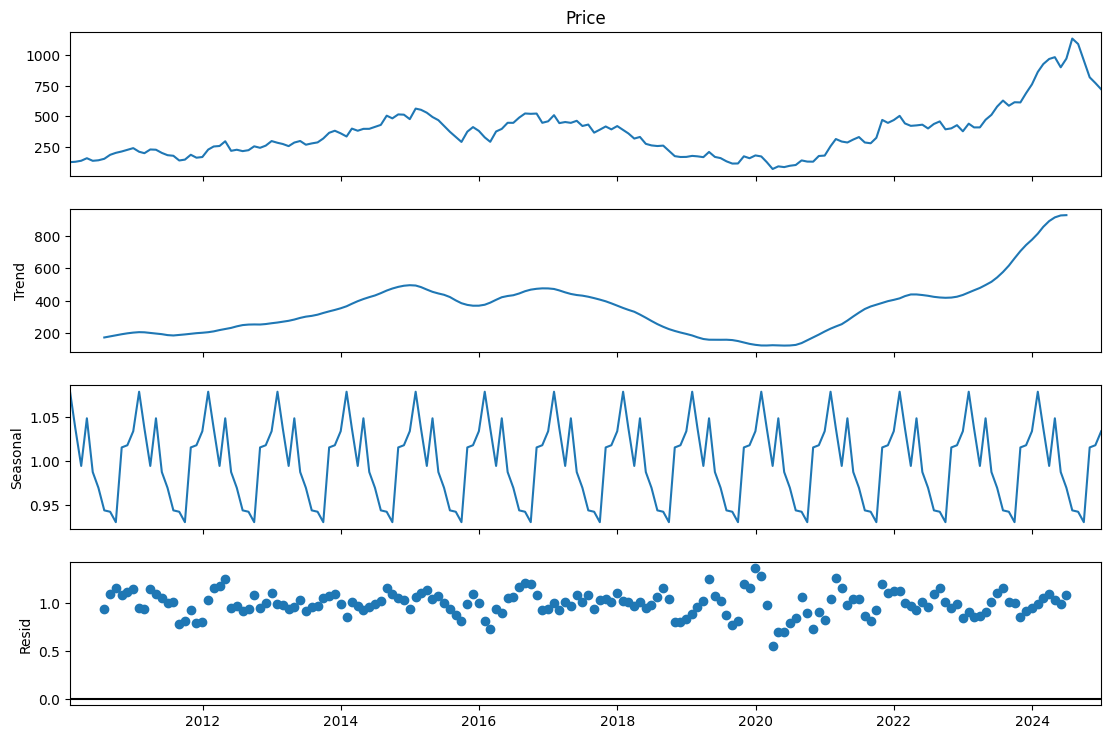

In [26]:
decompose = seasonal_decompose(df_monthly['Price'], model='multiplicative', period=12)
fig = decompose.plot()
fig.set_size_inches(12, 8)
plt.show()

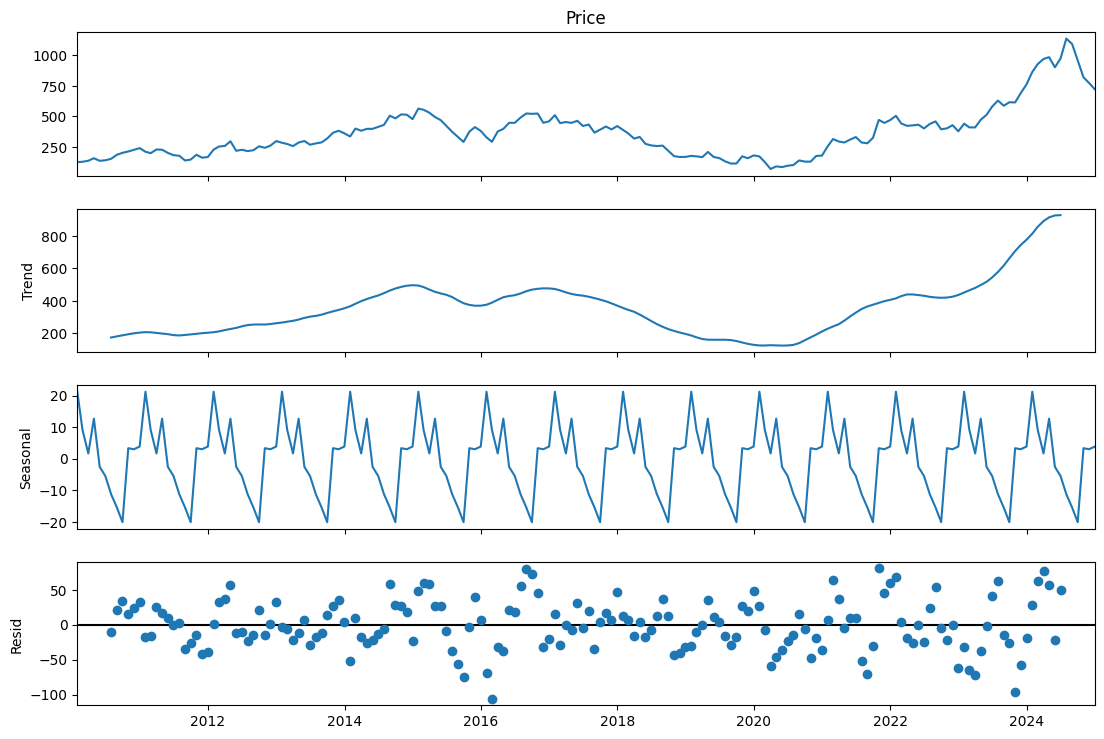

In [27]:
decompose = seasonal_decompose(df_monthly['Price'], model='additive', period=12)
fig = decompose.plot()
fig.set_size_inches(12, 8)
plt.show()

**Remark**:Comparing additive vs multiplicative decomposition confirms multiplicative is the better fit. The additive seasonal component is a fixed ±₹20 regardless of price level (an unrealistic ~13% swing in 2010 vs ~2% in 2024), and additive residuals grow substantially in magnitude over time (~±30 in 2010-2012 vs ~±80-100 in 2021-2024) — this heteroscedasticity indicates additive decomposition fails to account for the fact that seasonal/residual fluctuations scale with price level. Multiplicative residuals, by contrast, stayed roughly constant (~0.7-1.3) across the full period, confirming it as the more appropriate model for this series.

## 9. Summary & limitations

- **Best price-level model (selected on validation, evaluated once on test):** see Section 6
  output above.
- **Volatility model (GARCH):** evaluated independently on return volatility, not compared
  directly to the price-level models' RMSE.
- **Limitations:** a single train/val/test split (not full walk-forward CV) is used given the
  short monthly series (~180 points); a longer daily-frequency version or rolling-origin CV
  would give a more robust hyperparameter estimate. Macroeconomic/exogenous variables (e.g.
  crude oil prices, given Tata Motors' auto-sector exposure) were not included and are a
  natural next extension.